In [2]:
import unicodedata

import pandas as pd
from mpmath.libmp import normalize
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D,Dense,Dropout,Input,LSTM,Embedding,Normalization
import os
import datasets
from tensorflow.keras.optimizers import Adam
from datasets import Dataset,DatasetDict
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

C:\Users\LOQ\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data=pd.read_csv("btc2.csv",thousands=',')
data

,Date,Price,Open,High,Low,Vol.,Change
0,3/24/2024,67211.9,64036.5,67587.8,63812.9,65.59K,4.96%
1,3/23/2024,64037.8,63785.6,65972.4,63074.9,35.11K,0.40%
2,3/22/2024,63785.5,65501.5,66633.3,62328.3,72.43K,-2.62%
3,3/21/2024,65503.8,67860.0,68161.7,64616.1,75.26K,-3.46%
4,3/20/2024,67854.0,62046.8,68029.5,60850.9,133.53K,9.35%
...,...,...,...,...,...,...,...
4994,7/22/2010,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,7/21/2010,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,7/20/2010,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,7/19/2010,0.1,0.1,0.1,0.1,0.57K,0.00%


In [4]:
cls=["Price","Open","High","Low","Change","Vol."]


In [5]:
data=data.dropna(subset=cls)
print(data)

           Date    Price     Open     High      Low     Vol.  Change
0     3/24/2024  67211.9  64036.5  67587.8  63812.9   65.59K   4.96%
1     3/23/2024  64037.8  63785.6  65972.4  63074.9   35.11K   0.40%
2     3/22/2024  63785.5  65501.5  66633.3  62328.3   72.43K  -2.62%
3     3/21/2024  65503.8  67860.0  68161.7  64616.1   75.26K  -3.46%
4     3/20/2024  67854.0  62046.8  68029.5  60850.9  133.53K   9.35%
...         ...      ...      ...      ...      ...      ...     ...
4994  7/22/2010      0.1      0.1      0.1      0.1    2.16K   0.00%
4995  7/21/2010      0.1      0.1      0.1      0.1    0.58K   0.00%
4996  7/20/2010      0.1      0.1      0.1      0.1    0.26K   0.00%
4997  7/19/2010      0.1      0.1      0.1      0.1    0.57K   0.00%
4998  7/18/2010      0.1      0.0      0.1      0.1    0.08K   0.00%

[4993 rows x 7 columns]


In [6]:
data=data.iloc[::-1].reset_index(drop=True)


In [7]:
data.isnull().sum()

Date      0
Price     0
Open      0
High      0
Low       0
Vol.      0
Change    0
dtype: int64

In [8]:
print(data.columns.tolist())
print(data.head(2))

['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change']
        Date  Price  Open  High  Low   Vol. Change
0  7/18/2010    0.1   0.0   0.1  0.1  0.08K  0.00%
1  7/19/2010    0.1   0.1   0.1  0.1  0.57K  0.00%


In [9]:
print(data.columns.tolist())
print(data.shape)
print(data.head(2))

['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change']
(4993, 7)
        Date  Price  Open  High  Low   Vol. Change
0  7/18/2010    0.1   0.0   0.1  0.1  0.08K  0.00%
1  7/19/2010    0.1   0.1   0.1  0.1  0.57K  0.00%


In [10]:
def convert_vol(v):
    v=str(v)
    if v.endswith('K'):
        return float(v[:-1])*1_000
    elif v.endswith('M'):
        return float(v[:-1])*1_000_000
    elif v.endswith('B'):
        return float(v[:-1])*1_000_000_000
    else:
        return float(v)

data['Vol.']=data['Vol.'].apply(convert_vol)
data[cls].head()
data['Change']=data['Change'].str.rstrip('%').astype(float)

In [11]:
print(data['Vol.'].dtypes)

float64


In [12]:
print(data['Change'].dtypes)

float64


In [13]:
print(data['Vol.'])

0           80.0
1          570.0
2          260.0
3          580.0
4         2160.0
          ...   
4988    133530.0
4989     75260.0
4990     72430.0
4991     35110.0
4992     65590.0
Name: Vol., Length: 4993, dtype: float64


In [14]:
print(data['Change'])

0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
        ... 
4988    9.35
4989   -3.46
4990   -2.62
4991    0.40
4992    4.96
Name: Change, Length: 4993, dtype: float64


In [15]:
print(data['Change'].dtype)
print(data['Change'].apply(type).value_counts())


float64
Change
<class 'float'>    4993
Name: count, dtype: int64


In [16]:
split_r=0.8
split=int(len(data)*split_r)
train=data[:split][cls]
test=data[split:][cls]


In [17]:
from sklearn.preprocessing import MinMaxScaler
ii=MinMaxScaler()
train_s=ii.fit_transform(train)
test_s=ii.transform(test)

In [18]:
data.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change'], dtype='object')

In [19]:
def make_sequence(arr, seq_len=20):
    x,y=[],[]
    for i in range(len(arr)-seq_len):
        x.append(arr[i:i+seq_len])
        y.append(arr[i+seq_len,0])
    return np.array(x,dtype=np.float32), np.array(y, dtype=np.float32)

x_train_full,y_train_full=make_sequence(train_s)
x_test,y_test=make_sequence(test_s)

val_split=int(len(x_train_full)*0.85)
x_train,y_train=x_train_full[:val_split],y_train_full[:val_split]
x_val,y_val=x_train_full[val_split:],y_train_full[val_split:]

print('train:',x_train.shape,'val:',x_val.shape,'test:',x_test.shape)

train: (3377, 20, 6) val: (597, 20, 6) test: (979, 20, 6)


In [20]:
print(len(train))
print(len(test))

3994
999


In [21]:
print(x_train.shape)

(3377, 20, 6)


In [22]:
model=Sequential()

model.add(LSTM(112,return_sequences=True,input_shape=(20,6)))
model.add(Dropout(0.3))
model.add(LSTM(32,return_sequences=True))
model.add(LSTM(16,return_sequences=False))
model.add(Dense(1,activation='linear'))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 112)        │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 112)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 32)         │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,025 (293.07 KB)

 Trainable params: 75,025 (293.07 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss="mse",optimizer=Adam(learning_rate=0.0001),metrics=["mae"])

In [25]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [26]:
history=model.fit(x_train,y_train,batch_size=100,epochs=30,validation_data=(x_val,y_val),callbacks=[early_stop])

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0027 - mae: 0.0356 - val_loss: 0.0503 - val_mae: 0.1566
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.5385e-04 - mae: 0.0092 - val_loss: 0.0093 - val_mae: 0.0539
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.2802e-04 - mae: 0.0058 - val_loss: 0.0131 - val_mae: 0.0653
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.2306e-04 - mae: 0.0055 - val_loss: 0.0125 - val_mae: 0.0628
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.2357e-04 - mae: 0.0055 - val_loss: 0.0135 - val_mae: 0.0659
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.1986e-04 - mae: 0.0054 - val_loss: 0.0131 - val_mae: 0.0642
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.2121e-04 - mae: 0.0054 - val_loss: 0.0134 - val_mae: 0.0647
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


In [28]:
model.save("btc2.keras")

In [29]:
print(x_train.shape)

(3377, 20, 6)


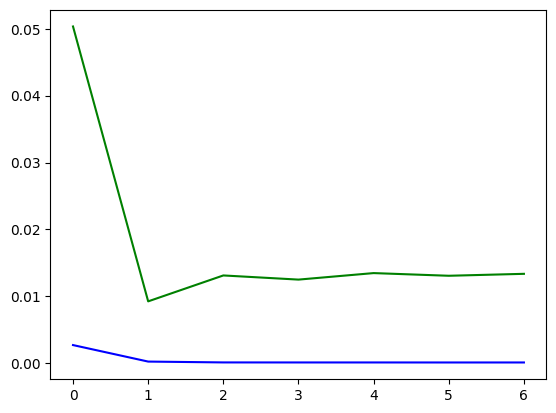

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],label="loss",color ="blue")
plt.plot(history.history["val_loss"],label="val loss",color="green")

In [31]:
l20=test_s[-20:]
l20=l20.reshape(1,20,6)
pred=model.predict(l20)
dummy=np.zeros((1,6))
dummy[0,1]=pred[0,0]
pred_price=ii.inverse_transform(dummy)[0,1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


In [32]:
print(f"{pred_price:,.2f}")

46,250.82


In [33]:
print(pred)
print(pred_price)


[[0.7278527]]
46250.81767537594


In [34]:
print(data["Price"].tail())


4988    67854.0
4989    65503.8
4990    63785.5
4991    64037.8
4992    67211.9
Name: Price, dtype: float64


In [35]:
model=load_model("btc2.keras")

In [36]:
model.evaluate(x_test, y_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213 - mae: 0.0941


[0.02131360024213791, 0.0940803587436676]